# Task 2 - City Analysis

#### Objective
Identify the city with the most restaurants, calculate average 
ratings per city, and find the city with the highest average rating.

Step 1 → Load data and peek at City column

Step 2 → Count restaurants per city using value_counts()

Step 3 → Find city with most restaurants

Step 4 → Calculate average rating per city using groupby()

Step 5 → Find city with highest average rating

Step 6 → Visualize top 10 cities by average rating

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Restaurant Analysis.xlsx')
df.columns = df.columns.str.replace('ï»¿', '')

In [3]:
df['City'].head(10)

0         Makati City
1         Makati City
2    Mandaluyong City
3    Mandaluyong City
4    Mandaluyong City
5    Mandaluyong City
6          Pasay City
7          Pasay City
8          Pasay City
9          Pasig City
Name: City, dtype: object

### Finding the City with Most Restaurants

We count how many restaurants exist in each city by counting 
how many times each city name appears in the dataset.

In [4]:
city_counts = df['City'].value_counts()
print(city_counts.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


In [5]:
top_city = city_counts.idxmax()
print("City with most restaurants:", top_city)
print("Number of restaurants:", city_counts.max())

City with most restaurants: New Delhi
Number of restaurants: 5473


#### Observation 
New Delhi has the most restaurants in the dataset — 5,473 in total. The next city, Gurgaon, has only 1,118, which means New Delhi has nearly 5 times more restaurants than any other city. This tells us that the data is mostly focused on New Delhi, with other cities having fewer entries.

### Average Rating Per City

We group restaurants by city and calculate the average 
rating for each city to compare performance across cities.

In [6]:
city_avg_rating = df.groupby('City')['Aggregate rating'].mean()
print(city_avg_rating.sort_values(ascending=False).head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


In [7]:
best_rated_city = city_avg_rating.idxmax()
print("City with highest average rating:", best_rated_city)
print("Average rating:", round(city_avg_rating.max(), 2))

City with highest average rating: Inner City
Average rating: 4.9


#### Observation 
Inner City has the highest average rating of 4.90 out of 5, but it probably has very few restaurants. So if just one restaurant there is really good, it makes the whole city's average look high. This can be misleading.
New Delhi has the most restaurants but is not in the top 10 for ratings. This means more restaurants does not always mean better food or service.

### Visualizing Average Ratings by City

A bar chart showing the top 10 cities with highest average ratings.

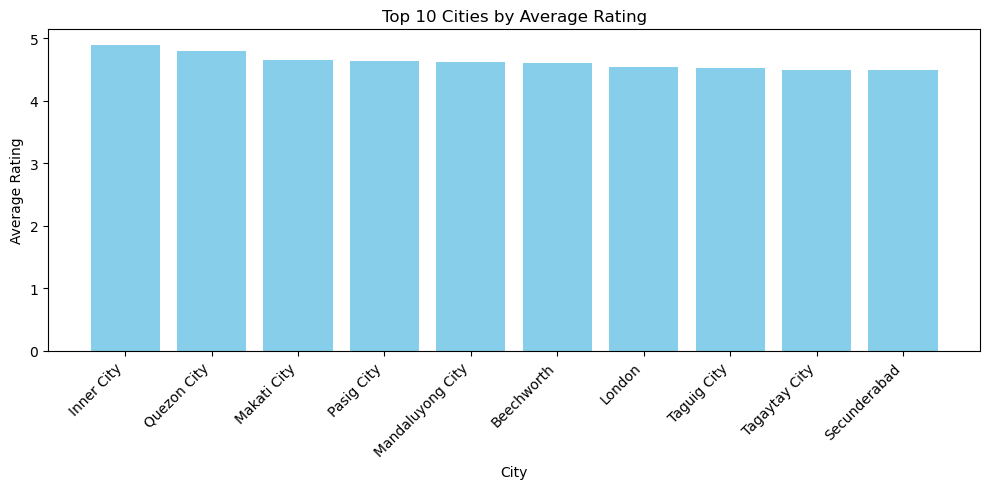

In [8]:
#sort all cities by rating from high to low, then keep only the top 10.
top10_cities = city_avg_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_cities.index, top10_cities.values, color='skyblue')
plt.title('Top 10 Cities by Average Rating')
plt.xlabel('City')
plt.ylabel('Average Rating')
#Tilts the city name labels on X axis by 45 degrees so they don't overlap and are easy to read.
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observation

The bar chart shows the top 10 cities by average rating. 
Inner City leads with 4.90 followed by Quezon City at 4.80. 
All top 10 cities have ratings above 4.50 which shows that 
highly rated restaurants are spread across different cities 
and not concentrated in one place.